# 発展課題3（演習3：パイプラインを組む）

演習3-2 では「上限は2つある」と**表で言っただけ**でした。ここでは、それを**自分の環境で実際に見分けます。**

```
上限A = 1000ms ÷ 一番遅い段の時間(ms)　[FPS]  
上限B = 1000ms ÷ (データ１つの処理に CPU が使われた時間*¹ ÷ 速度倍率*²) [FPS]  
```
*1) パイプラインのデータ1つ（画像1枚）を処理完了するためにCPUが使われる時間 [mS]、外部（ディスク・アクセラレータ・画面）の返事待ちや、
  キューの順番待ちは含めない。  
*2) CPUコア数によってどれくらい速度が速くなるか。  
1)2)共に実測するのが望ましい。  

**実測FPS は2つの小さいほうを超えられません。**
- **上限A は流れ作業から導出。** 全体の速さは一番遅い係の速さです。Read 10 / Infer 60 / Show 30ms なら `1000 ÷ 60 = 16.7 FPS`。**段の切り方と各段の人数で動きます** ―― Infer を2人にすれば実質 30ms になり、33.3 に上がります。

- **上限B はマシンの性能で決まる。** CPU を使う場所が足りなければ、それ以上は流せません。**人を何人並べても上限B は動きません。** 分母も分子も、スレッドの本数とは無関係だからです。

見分けが要るのは、**次にやることが正反対**だからです。

- **上限A で止まっている** ⇒ 段の切り方・人数を変えれば伸びる
- **上限B で止まっている** ⇒ 何をしても伸びない。**計算量そのものを減らすしかない**

3問あります。**全部やる必要はありません。**

- [問3-1 段に分けると、どれだけ速くなるか](#scrollTo=adv03_pipeline_02)（実験・上限A）
- [問3-2 一番遅い段の人を増やしていくと](#scrollTo=adv03_pipeline_06)（実験・上限B）
- [問3-3 キューの長さでボトルネックを当てる](#scrollTo=adv03_pipeline_10)（実験・犯人さがし）

以下、**構成①〜③**の番号は3問を通して同じものを指します。

```
構成①  直列（1本の for ループ）
構成②  3段（Read / Infer / Show を1本ずつ）
構成③  Infer 2人
```

> **最初に下のセル（`cq.h`）を1回だけ実行してください。**
> 演習2で使ったキューです。以降のプログラムはこれを `#include` します。

In [ ]:
%%writefile cq.h
// ============================================================
//  cq.h ―― この演習で使うスレッドセーフなキュー
//  中身は読まなくてよい。使うのは push / pop / size の3つだけ。
// ============================================================
#pragma once
#include <queue>
#include <mutex>
#include <condition_variable>

template <typename T>
class ConcurrentQueue {
public:
    explicit ConcurrentQueue(std::size_t capacity) : capacity_(capacity) {}

    // 入れる。満杯なら空くまで待つ
    void push(const T& v) {
        std::unique_lock<std::mutex> lk(mtx_);
        can_push_.wait(lk, [this] { return q_.size() < capacity_; });
        q_.push(v);
        if (q_.size() > peak_) peak_ = q_.size();
        lk.unlock();
        can_pop_.notify_one();
    }

    // 取り出す。空なら来るまで待つ（失敗しない）
    T pop() {
        std::unique_lock<std::mutex> lk(mtx_);
        can_pop_.wait(lk, [this] { return !q_.empty(); });
        T v = q_.front(); q_.pop();
        lk.unlock();
        can_push_.notify_one();
        return v;
    }

    std::size_t size() const { std::lock_guard<std::mutex> g(mtx_); return q_.size(); }
    std::size_t peak() const { std::lock_guard<std::mutex> g(mtx_); return peak_; }   // 観測用：並んだ最大数

private:
    std::queue<T> q_;
    std::size_t capacity_;
    std::size_t peak_ = 0;
    mutable std::mutex mtx_;
    std::condition_variable can_pop_;    // 「取り出せるようになった」
    std::condition_variable can_push_;   // 「入れられるようになった」
};

## 問3-1. 段に分けると、どれだけ速くなるか

各段の処理時間はこれだけです。

```
Read   10ms
Infer  60ms （平均。1個ごとに 35〜85ms とばらつく）
Show   30ms
```

測るのは2つです。

- **構成①** 直列（1本の for ループ。キューもスレッドも使わない） … スレッド **0本**
- **構成②** 3段パイプライン（Read / Infer / Show を1本ずつ） … スレッド **3本**

> キューの容量は 2本とも **4** に固定します（コードの `const std::size_t CAP = 4;`）。
> 演習3-1 の式では 2 で足りるので、少し余裕をとった値です。
> ここで見たいのは段の分け方なので、容量は動かしません。

**実行前に予測してください。**

- ① は1個を通すのに `10 + 60 + 30 = 100ms` かかるので **10 FPS** が基準です
- ② は**3段に分けたのだから、3倍の 30 FPS になるでしょうか**

In [ ]:
%%writefile adv03a.cpp
// 問3-1  直列 と 3段パイプラインを比べる
#include <iostream>
#include <iomanip>
#include <thread>
#include <chrono>
#include <atomic>
#include "cq.h"
using namespace std::chrono;

// ---- 各段の仕事。「CPU」＝コアを占有する、「外部」＝コアを手放す ----
//                        CPU    外部     合計
const int READ_CPU =  2, READ_WAIT =  8;     //  10ms  （外部＝ディスク）
const int INF_CPU  = 35;                     //  外部は 0/25/50 → 平均 60ms（アクセラレータ）
const int SHOW_CPU =  3, SHOW_WAIT = 27;     //  30ms  （外部＝画面）

const int N = 60;                  // 流すフレーム数（少なすぎると立ち上がりの影響でぶれる）
const std::size_t CAP = 4;         // キューの容量（2本とも）

// ---- 1ms ぶん「本当に計算する」道具（sleep ではコアを手放してしまう）----
long calib = 0;
std::atomic<long> sink{0};        // 複数スレッドから足すので atomic（volatile では守れない）
long burn(long n) { long s = 0; for (long i = 0; i < n; i++) s += (i * 2654435761u) % 7; return s; }
void calibrate() {
    long n = 100000;
    for (;;) {
        auto t0 = steady_clock::now(); sink.fetch_add(burn(n), std::memory_order_relaxed);
        auto us = duration_cast<microseconds>(steady_clock::now() - t0).count();
        if (us > 30000) { calib = n * 1000 / us; return; }
        n *= 2;
    }
}
void stage(int cpu_ms, int ext_ms) {
    if (cpu_ms) sink.fetch_add(burn(calib * cpu_ms), std::memory_order_relaxed);  // CPU：コアを占有
    if (ext_ms) std::this_thread::sleep_for(milliseconds(ext_ms));                // 外部：コアを手放す
}
void do_read()       { stage(READ_CPU, READ_WAIT); }
void do_infer(int i) { stage(INF_CPU, (i % 3) * 25); }
void do_show()       { stage(SHOW_CPU, SHOW_WAIT); }

// Infer 1個ぶんの内訳を足し込む場所（Infer スレッド1本しか触らないので鍵は要らない）
long long us_pop = 0, us_work = 0, us_push = 0;

// 演習4-2 の作法④：最初の数個はキャッシュが冷えているので捨てる
void warmup() { for (int i = 0; i < 3; i++) { do_read(); do_infer(i); do_show(); } }

// ================= (1) 直列 ―― 1本の for ループ =================
double serial() {
    auto t0 = steady_clock::now();
    for (int i = 0; i < N; i++) { do_read(); do_infer(i); do_show(); }
    return 1000.0 * N / duration_cast<milliseconds>(steady_clock::now() - t0).count();
}

// ================= (2) 3段 ―― Read / Infer / Show を1本ずつ =================
double pipeline3() {
    ConcurrentQueue<int> q1(CAP), q2(CAP);
    auto t0 = steady_clock::now();
    std::thread rd  ([&]{ for (int i = 0; i < N; i++) { do_read();        q1.push(i);  } });
    std::thread inf ([&]{
        us_pop = us_work = us_push = 0;
        for (int i = 0; i < N; i++) {
            auto a = steady_clock::now(); int x = q1.pop();   // 取り出し待ち
            auto b = steady_clock::now(); do_infer(x);        // 処理（設計では平均 60ms）
            auto c = steady_clock::now(); q2.push(x);         // 入れ待ち
            auto d = steady_clock::now();
            us_pop  += duration_cast<microseconds>(b - a).count();
            us_work += duration_cast<microseconds>(c - b).count();
            us_push += duration_cast<microseconds>(d - c).count();
        }
    });
    std::thread show([&]{ for (int i = 0; i < N; i++) { int x = q2.pop();  (void)x; do_show(); } });
    rd.join(); inf.join(); show.join();
    return 1000.0 * N / duration_cast<milliseconds>(steady_clock::now() - t0).count();
}

int main() {
    calibrate();
    warmup();
    std::cout << std::fixed << std::setprecision(1)
      << "各段の時間（計算＋待ち）: Read 10ms / Infer 60ms(平均) / Show 30ms\n"
      << "1個を直列で通す時間     : 10 + 60 + 30 = 100ms\n"
      << "キューの容量            : 2本とも " << CAP << "\n\n"
      << "上限A = 1000 / 一番遅い段の時間\n\n"
      << "  上限A  実測FPS   構成\n";

    double s = serial();
    std::cout << std::setw(7) << "-" << std::setw(9) << s
              << "   直列（1本の for ループ）\n";
    double p = pipeline3();
    std::cout << std::setw(7) << (1000.0 / 60) << std::setw(9) << p
              << "   3段（Read / Infer / Show を1本ずつ）\n\n";
    std::cout << "3段にして " << (p / s) << " 倍\n\n";

    // ---- 3段のとき Infer の1個あたりが何に使われていたか ----
    double pop = us_pop / 1000.0 / N, wrk = us_work / 1000.0 / N, psh = us_push / 1000.0 / N;
    double tot = pop + wrk + psh;
    std::cout << "3段のときの Infer 1個あたりの内訳\n"
              << "    取り出し待ち " << std::setw(6) << pop << "ms\n"
              << "    処理         " << std::setw(6) << wrk << "ms   <- 60ms のはず\n"
              << "    入れ待ち     " << std::setw(6) << psh << "ms\n"
              << "    合計         " << std::setw(6) << tot << "ms"
              << "   -> 上限A(実測) = " << (1000.0 / tot) << " FPS\n\n"
              << "「処理」が 60ms より大きく伸びていたら、CPU が足りていません（問3-2 へ）。\n"
              << "そのときは 上限A(設計) ではなく 上限A(実測) と実測FPS を見比べてください。\n";
    return 0;
}

In [ ]:
!g++ -std=c++17 -pthread -O2 adv03a.cpp -o adv03a && ./adv03a

### 問3-1 の解答 ―― 3段に分けても、3倍にはならない

```
  上限A  実測FPS   構成
      -     10.7   ① 直列（1本の for ループ）
   16.7     16.4   ② 3段（Read / Infer / Show を1本ずつ）

3段にして 1.5 倍

3段のときの Infer 1個あたりの内訳
    取り出し待ち    0.2ms
    処理           60.2ms   <- 60ms のはず
    入れ待ち        0.1ms
    合計           60.5ms   -> 上限A(実測) = 16.5 FPS
```

（**数字よりも、3倍に遠く届かないこと**を見てください。実測FPS はマシンによって大きく変わります）

```
上限A = 1000 / 一番遅い段の時間 = 1000 / 60ms = 16.7 FPS
```

流れ作業なので、全体の速さは**一番遅い係の速さ**で決まります。ここでは Infer の 60ms です。

> **決めているのは「段の数」ではなく、「一番遅い段」。**

得られる倍率は、分ける前から計算できていました ―― `100ms ÷ 60ms = 1.67倍`。

**16.7 に届かなかった人へ。** 最後に出した**内訳が、その理由を教えてくれます。**

- **「処理」が 60ms のまま**（上の 60.2ms）… 計算力は足りています。
  残りの数%は**立ち上がりと終わり** ―― 最初の1個が Infer に届くまでの 10ms と、
  最後の1個の Show の 30ms は、Infer が回っていない時間だからです
- **「処理」が 60ms より大きく伸びている** … **CPU が足りていません。**
  **60ms のはずの Infer が 60ms で終わっていない** ―― 上限A の前提そのものが崩れています。
  そのときは **上限A(実測)** のほうを実測FPS と見比べてください。**必ず一致します。**
  **「一番遅い段が決める」は崩れておらず、崩れたのは 60ms という設計値のほう**です。
  なぜ伸びるのかは**問3-2**で扱います
- **「取り出し待ち」が大きい** … Read が追いついていません（問3-3）

**ばらつきは効いていません。** Infer をぴったり 60ms に固定しても FPS は変わりません。
Infer は `pop` でも `push` でも待っておらず、**ばらつきは平均に均されます。**
ばらつきが効くのは**容量が足りないとき**だけです（演習3-1【B】）。

> **一番遅い段の時間は、数えるものではなく測るもの。**

**なお、このとき CPU は遊んでいます。** Infer は 60ms のあいだずっと計算しているわけではないので、
コアには空きがあります。**それでも 16.7 が上限**なのは、
**Infer が1本しかなく、1個を出し終えるまで次に取りかかれない**からです。
上限A は「並べ方」の制約であって、CPU が足りる・足りないとは別の話です。

**では、その空きを使うにはどうするか。人を増やすしかありません。** それが問3-2 です。

### 図で見る ―― 誰が止めているのか

（Infer の時間は平均の 60ms に固定して描いています。色は1個ごとに変えてあります）

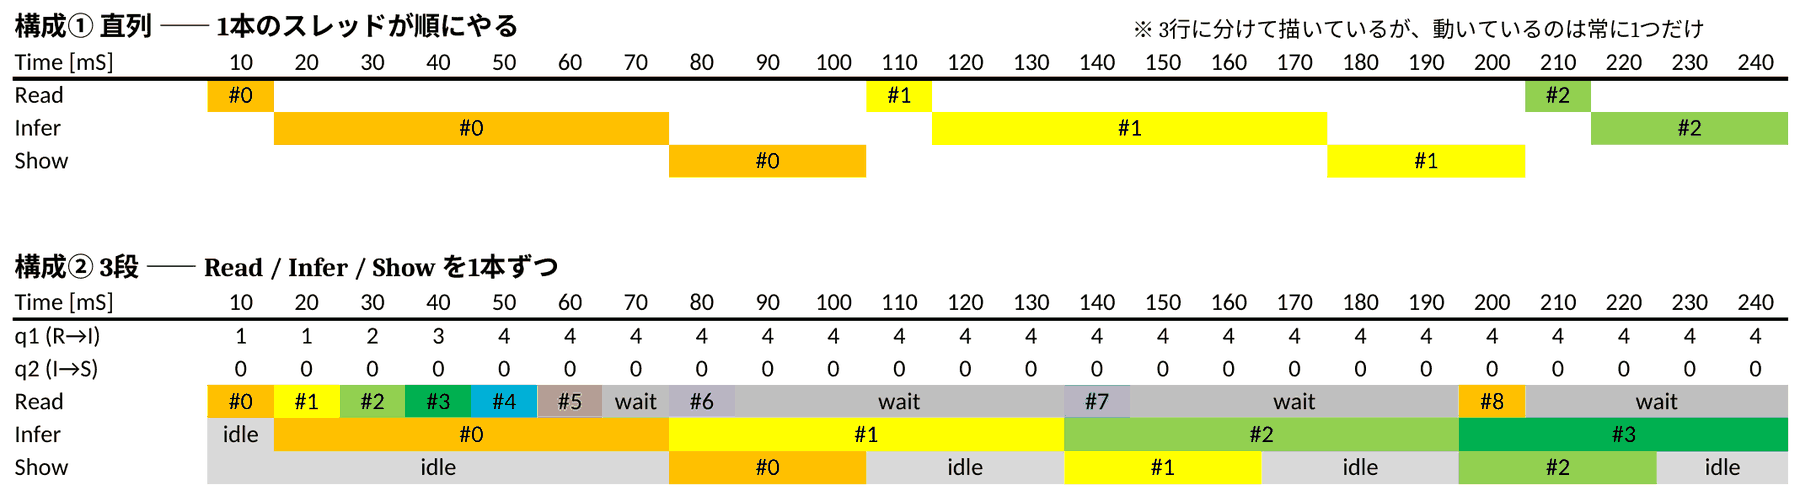

> 🔍 **図が小さいときは** [この図を原寸で開く](https://raw.githubusercontent.com/takgto/cpp-lab/main/img/pipe_31.png)（別タブ）。
> ブラウザのズーム（`Ctrl` + マウスホイール）でも拡大できます。

**構成①** ―― 3行に分けて描いていますが、**色が付いているのは常に1つだけ**です。
`#0` が Show を出終わるのが 100ms、`#1` が 200ms ―― **1個 100ms、10 FPS。**

**構成②** ―― 3行が同時に色を持ちます。**見てほしいのは「すき間」**です。

- **Infer の行には、すき間が1つもありません** ⇒ **この段が犯人**
- **Read は `wait` だらけ。** q1 が満杯（4）で、作っても入れる場所がありません
- **Show は `idle` と処理が交互。** 60ms に1個しか回ってきません

出口は 100ms, 160ms, 220ms … と **60ms おき ＝ 16.7 FPS。**
**Infer の 60ms が、そのまま出口の間隔になっています。**

> **すき間のない段が全体の速さを決めている。**

**すき間のない段の人を増やせば、その空きが使えます。** それが問3-2 です。

## 問3-2. 一番遅い段の人を増やしていくと

### その前に ―― 60ms のあいだ、ずっと CPU が動いているわけではない

上限A は「一番遅い段の時間」だけで決まりました。**もう1つの上限は、その時間の中身で決まります。**

各段の 10 / 60 / 30ms は、**CPU 自身が計算している区間**と、
**アクセラレータ・ディスク・画面といった CPU の外側が仕事をしている区間**に分かれます。
以下、後者を **「外部」** と呼びます。

```
              CPU     外部      合計
Read           2ms     8ms     10ms   ← 外部 = ディスク
Infer         35ms    25ms     60ms   ← 外部 = アクセラレータ
Show           3ms    27ms     30ms   ← 外部 = 画面
```

- **CPU の区間**はコアを占有するので、同時に進められるのは**マシンの計算力まで**
- **外部の区間**はコアを手放しているので、**その裏で他のスレッドが動けます**（演習1-3）

（キューの `push` / `pop` で止まるのとは別物です。あちらは順番待ち、こちらは外部の仕事中）

そして **1個の処理に CPU が実際に使われた時間は、数えるのではなく測ります。**

```cpp
timespec ts; clock_gettime(CLOCK_THREAD_CPUTIME_ID, &ts);   // このスレッドが実際に CPU を使った時間
```

この時計は**外部の区間では進みません。** 3本ぶんを足してフレーム数で割れば **`CPU/個`** が出ます。
**これが上限B の分子の１つ、**でデータ１つの処理に CPU が使われた時間、表の `CPU/個` の列がそれです。

### 人を増やす

Infer を2人にします。人を増やせばその段は実質半分の時間になり、**上限A は倍に上がります。**

| 構成 | 内容 | 一番遅い段 | 上限A | スレッド |
|---|---|---|---|---|
| ② | 3段（Infer 1人 / Show 1人） | Infer 60ms | 16.7 | 3本 |
| ③ | Infer 2人 | Show 30ms | **33.3** | 4本 |

各段のスレッドは、人数によらず必ずこの形です。**2人とも同じキューから取り出し、同じキューに入れます。**

```cpp
while (まだある) {
    T x = 前のキュー.pop();     // 取り出す（空なら待つ）
    ...処理する...              // ここは鍵の外。ここだけが本当の仕事
    次のキュー.push(x);         // 入れる（満杯なら待つ）
}
```

> **コアは2つしかないのに、4本立てます。** 各段は外部の区間が長く、
> **そのあいだスレッドはコアを手放している**からです（演習1-3）。
> キューの容量は問3-1 と同じく **2本とも 4**。

> ⚠ **予測するには、走らせるマシンの計算力が要ります。**
> **ここでは Colab の標準環境を前提にしてください。実測するとこうでした。**
>
> ```
> hardware_concurrency() = 2
> Core(s) per socket: 1      ← 物理コアは 1個
> Thread(s) per core: 2      ← その1個を2本で分け合っている
>
>  本数   速度倍率
>    1      1.03
>    2      1.09      ← 2本にしても 1.1倍にしかならない
>    4      1.11
> ```
>
> **論理CPU が 2 でも、物理コアは 1個。** だから計算を2本に分けても速さはほぼ増えません。
> **計算力がもっと大きいマシンでは、答えが変わります。**
> このプログラムは、まずこの倍率を実測して表示します。

**実行前に予測してください。**

- ③ で上限A が 16.7 → 33.3 に**倍**になります。**実測も倍になるでしょうか**
- ならないとしたら、**何が止めているのでしょうか**
- そして **Show に届くデータの順番**はどうなるでしょうか

In [ ]:
%%writefile adv03b.cpp
// 問3-2  一番遅い段の人を増やしていく（上限A を上げると、どこで止まるか）
#include <iostream>
#include <iomanip>
#include <thread>
#include <vector>
#include <mutex>
#include <chrono>
#include <atomic>
#include <ctime>
#include "cq.h"
using namespace std::chrono;

const int READ_CPU =  2, READ_WAIT =  8;     //  10ms  （外部＝ディスク）
const int INF_CPU  = 35;                     //  外部は 0/25/50 → 平均 60ms（アクセラレータ）
const int SHOW_CPU =  3, SHOW_WAIT = 27;     //  30ms  （外部＝画面）

const int N = 60;                  // 少なすぎると立ち上がりの影響でぶれる
const std::size_t CAP = 4;

// このスレッドがこれまでに「実際に CPU を使った」時間(ms)。待っている間は増えない。
double thread_cpu_ms() {
    timespec ts; clock_gettime(CLOCK_THREAD_CPUTIME_ID, &ts);
    return ts.tv_sec * 1000.0 + ts.tv_nsec / 1e6;
}
std::atomic<double> cpu_total{0};                       // 3本ぶんの合計
void add_cpu(double from) {
    double v = thread_cpu_ms() - from, old = cpu_total.load();
    while (!cpu_total.compare_exchange_weak(old, old + v)) {}
}

long calib = 0;
std::atomic<long> sink{0};        // 複数スレッドから足すので atomic（volatile では守れない）
long burn(long n) { long s = 0; for (long i = 0; i < n; i++) s += (i * 2654435761u) % 7; return s; }
void calibrate() {
    long n = 100000;
    for (;;) {
        auto t0 = steady_clock::now(); sink.fetch_add(burn(n), std::memory_order_relaxed);
        auto us = duration_cast<microseconds>(steady_clock::now() - t0).count();
        if (us > 30000) { calib = n * 1000 / us; return; }
        n *= 2;
    }
}
void stage(int cpu_ms, int wait_ms) {
    if (cpu_ms)  sink.fetch_add(burn(calib * cpu_ms), std::memory_order_relaxed);
    if (wait_ms) std::this_thread::sleep_for(milliseconds(wait_ms));
}
void do_read()       { stage(READ_CPU, READ_WAIT); }
void do_infer(int i) { stage(INF_CPU, (i % 3) * 25); }
void do_show()       { stage(SHOW_CPU, SHOW_WAIT); }

// 演習4-2 の作法④：最初の数個はキャッシュが冷えているので捨てる
void warmup() { for (int i = 0; i < 3; i++) { do_read(); do_infer(i); do_show(); } }

// hardware_concurrency() を信じず、「1本のときの何倍の速さで計算が進むか」を実測する。
// コアの数（整数）ではなく倍率（実数）が返る。
double measure_speedup(unsigned hw) {
    long U = calib * 200;              // 短すぎるとぶれるので 200ms 分
    auto t0 = steady_clock::now();
    sink.fetch_add(burn(U), std::memory_order_relaxed);
    double one = duration_cast<microseconds>(steady_clock::now() - t0).count();

    std::vector<std::thread> th;
    t0 = steady_clock::now();
    for (unsigned k = 0; k < hw; k++) th.emplace_back([&]{ sink.fetch_add(burn(U), std::memory_order_relaxed); });
    for (auto& t : th) t.join();
    double many = duration_cast<microseconds>(steady_clock::now() - t0).count();
    return hw * one / many;
}

// Infer を ninfer 人、Show を nshow 人にした3段パイプライン。
// 人を増やしても、2人とも同じキューから取り出し、同じキューに入れる。
struct Result { double fps; double cpu; int inv; };
Result pipeline(int ninfer, int nshow) {
    ConcurrentQueue<int> q1(CAP), q2(CAP);
    int inv = 0, last = -1;
    std::mutex m;
    cpu_total = 0;

    auto t0 = steady_clock::now();
    std::thread rd([&]{ double c = thread_cpu_ms();
        for (int i = 0; i < N; i++) { do_read(); q1.push(i); } add_cpu(c); });

    std::vector<std::thread> inf, sh;
    for (int k = 0; k < ninfer; k++)
        inf.emplace_back([&, k]{                       // ← k は値で捕まえる
            double c = thread_cpu_ms();
            for (int i = k; i < N; i += ninfer) { int x = q1.pop(); do_infer(x); q2.push(x); }
            add_cpu(c);
        });
    for (int k = 0; k < nshow; k++)
        sh.emplace_back([&, k]{
            double c = thread_cpu_ms();
            for (int i = k; i < N; i += nshow) {
                int x = q2.pop();
                do_show();
                std::lock_guard<std::mutex> g(m);
                if (x < last) inv++;                   // 前より小さい番号が来た＝追い越された
                last = x;
            }
            add_cpu(c);
        });

    rd.join(); for (auto& t : inf) t.join(); for (auto& t : sh) t.join();
    double ms = duration_cast<milliseconds>(steady_clock::now() - t0).count();
    return { 1000.0 * N / ms, cpu_total.load() / N, inv };   // CPU 時間は1個あたりに直す
}

double sp = 0, limitB = 0;        // 速度倍率と上限B（どちらも実測から）
void line(const char* label, double slowest, Result r) {
    std::cout << std::setw(7) << (1000.0 / slowest)
              << std::setw(7) << limitB
              << std::setw(9) << r.fps
              << std::setw(8) << r.cpu << "ms"
              << std::setw(6) << r.inv << "   " << label << "\n";
}

int main() {
    unsigned hw = std::thread::hardware_concurrency();
    calibrate();
    warmup();
    sp = measure_speedup(hw);

    std::cout << std::fixed << std::setprecision(1)
      << "各段の時間: Read 10ms / Infer 60ms(平均) / Show 30ms   キューの容量: 2本とも " << CAP << "\n\n";

    std::cout << std::setprecision(2)
      << "hardware_concurrency() = " << hw << " ですが、" << hw
      << "本で同時に計算させて速度を実測すると " << sp << " 倍でした\n"
      << "  （これはコアの数ではなく倍率です。整数になるとは限りません）\n\n";

    // 上限B の分母は、いちばん取り合いの少ない構成②で測った CPU/個 を使う
    Result r2 = pipeline(1, 1);
    limitB = 1000.0 * sp / r2.cpu;

    std::cout << std::setprecision(1)
      << "上限A = 1000 / 一番遅い段の時間                     ... 人数を変えると動く\n"
      << "上限B = 1000 x " << std::setprecision(2) << sp << std::setprecision(1)
      << " / " << r2.cpu << "ms = " << limitB << " FPS （目安）   ... 動かない\n\n";

    std::cout << "  上限A  上限B  実測FPS   CPU/個  乱れ   構成\n";
    line("3段（Infer 1人 / Show 1人）", 60, r2);
    line("Infer 2人",                   30, pipeline(2, 1));
    return 0;
}

In [ ]:
!g++ -std=c++17 -pthread -O2 adv03b.cpp -o adv03b && ./adv03b

### 問3-2 の解答 ―― 上限A を上げても、上限B で止まる

```
hardware_concurrency() = 2 ですが、2本で同時に計算させて速度を実測すると 1.12 倍でした
  （これはコアの数ではなく倍率です。整数になるとは限りません）

上限A = 1000 / 一番遅い段の時間                     ... 人数を変えると動く
上限B = 1000 x 1.12 / 59.1ms = 19.0 FPS （目安）   ... 動かない

  上限A  上限B  実測FPS   CPU/個  乱れ   構成
   16.7   19.0     12.6    59.1ms     0   ② 3段（Infer 1人 / Show 1人）
   33.3   19.0     21.2    64.8ms     4   ③ Infer 2人
```

- **上限A は 16.7 → 33.3 と倍**になりました。一番遅い段が Infer(60ms) から Show(30ms) に移ったためです
- **ところが実測は 12.6 → 21.2 で、1.7倍**。**倍にはなりません**
- 止めているのは上限A ではありません。**21.2 は上限B（目安 19）のあたり**で頭打ちになっています
- **`乱れ` が 0 から 4 に。** 2人で同時に処理すれば追い越しは必ず起きます（**付録A**）

**もう1人増やしても、もう伸びません。** 上限A は 33.3 のまま動かず、実測は上限B に当たっているからです。
**次にやるべきは人を増やすことではなく、1個あたりの計算量を減らすこと**です。

> **上限B を「目安」と書いてあるのは、実測が数割前後するからです。**
> 分子の速度倍率は「2本とも計算しっぱなし」という**いちばん条件の悪い測り方**で出しているので、
> 実際のパイプライン（計算しっぱなしにはならない）はこれを少し上回ることがあります。
> `CPU/個` も、人を増やすと 59.1 → 64.8 と増えて見えます ―― **計算量が増えたのではなく、
> ハイパースレッドで1本あたりが遅くなり、同じ仕事に CPU 時間が余計にかかったように見える**ためです。
> だから分母には、取り合いのいちばん少ない**構成②の値**を使っています。
> **数字の細かさではなく、「上限A を倍にしても実測は倍にならない」ほうを見てください。**

### 図で見る ―― すき間はどこへ移ったか

> ⚠ **この図は「コアが足りている」場合です**（＝上限A だけが効く世界）。
> **上限B は描いていません。** 実測が図のとおりにならないのは、そのためです。

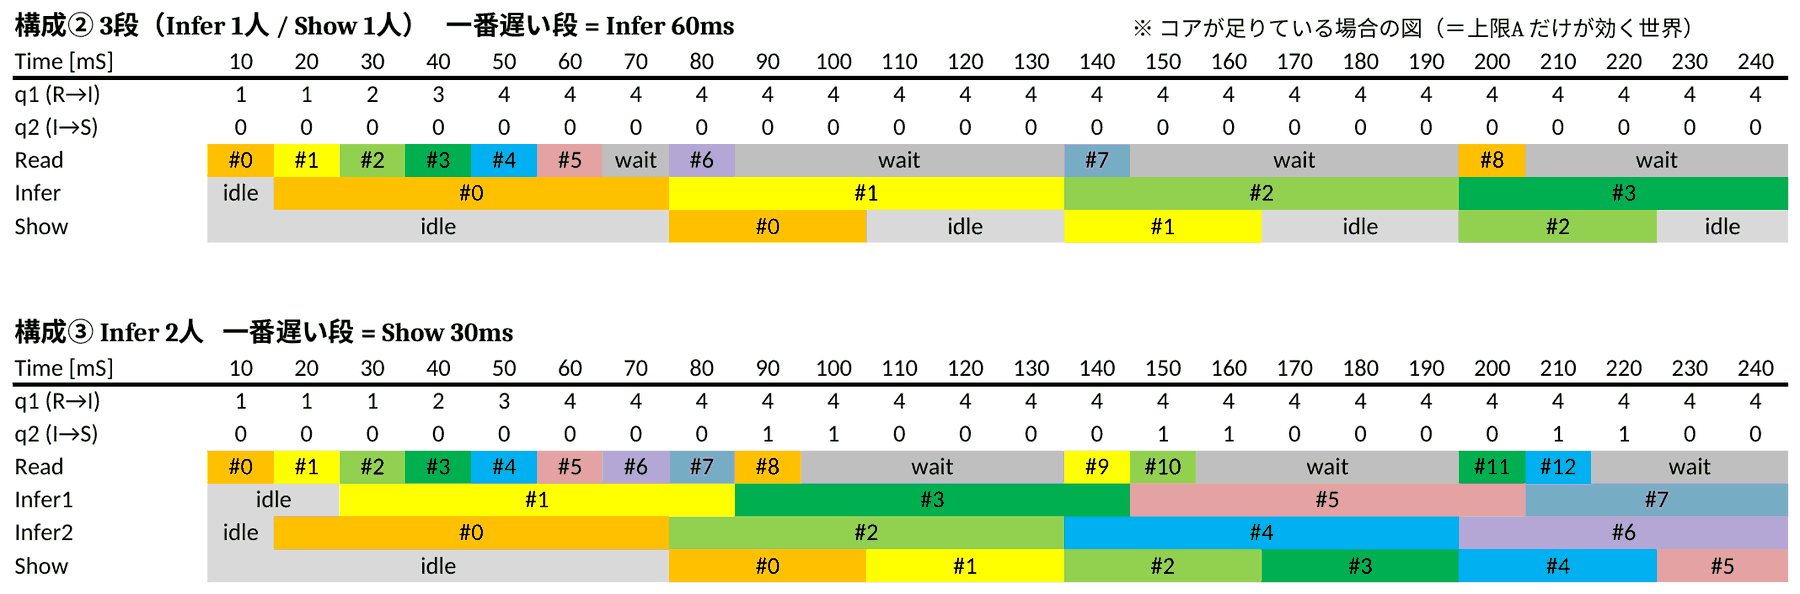

> 🔍 **図が小さいときは** [この図を原寸で開く](https://raw.githubusercontent.com/takgto/cpp-lab/main/img/pipe_32.png)（別タブ）。
> ブラウザのズーム（`Ctrl` + マウスホイール）でも拡大できます。

**すき間が Infer から Show へ移りました。** ② では Infer にすき間がなく、
③ では Infer1 と Infer2 が交互に動いて、代わりに **Show のすき間が無くなります。**
図の上では出口が 60ms おき → 30ms おきになり、上限A が倍になったことがそのまま見えます。

**ところが実測は 1.65倍にしかなりません。**
図に描いていないもう1つの上限 ―― **マシンの計算力**（上限B）が効いているからです。
**この図と実測の差、それが上限B です。**

### 上限B ―― 人を増やしても動かないほうの上限

```
上限B = 1000 × 速度倍率 ÷ CPU/個
```

**分子も分母も実測値**で、**式にスレッドの本数も段の数も出てきません。**
上の表が示すとおり、人を何人並べても `CPU/個` は変わらないからです。

> **人を増やして減るのは「外部を待っている時間」であって、「CPU を使う時間」ではない。**

なお**実測が上限にきっちり届くことはありません。** キューの出し入れ、スレッドの入れ替え、
キャッシュの奪い合いの分だけ目減りします。**上限は天井であって、達成目標ではありません。**

**「乱れ」の列**は、Show に届いた番号が前より小さかった回数です。人を増やしたとたんに出ています
（**付録A**）。

### 「1.10」とは何か ―― コアの数ではありません

コアの数は整数です。**1.10 はコアの数ではなく、速度の倍率**です。

```
同じ計算を 1本のスレッドでやったときの時間  = one
同じ計算を hw 本 同時にやったときの時間      = many

速度倍率 = hw × one ÷ many
```

2本で完全に2倍速くなれば `many = one` で倍率 2.0、まったく重ならなければ 1.0。
**割り算の答えなので、整数にはなりません。**

> **分母は「理想」ではなく「スレッド1本のとき」です。**
> 理想（2本ぶん）に対する割合なら `1.10 ÷ 2 =` **0.55（55%）**。
> 上限B に使うのは前者です ―― 分母の `CPU/個` が**1本ぶんの CPU 時間**なので、基準を揃える必要があります。

同じ「スレッド2本」でも、ハードウェアで倍率は変わります。

| 物理コア | ハイパースレッド | 2本立てたときの倍率 | 理由 |
|---|---|---|---|
| 1個 | なし | **1.0倍** | 時分割するだけ。合計の計算量は増えない |
| 1個 | あり（論理2） | **1.1〜1.5倍** | 同時に走るが、計算回路を共有するので1本あたりが遅い（Colab は 1.1倍） |
| 2個 | なし | **1.9〜2.0倍** | ほぼ理想どおり |

**`hardware_concurrency()` は、この3つのどれでも 2 と答えます。**
1.10 が出たのが「2個あるのに時間で割れている」のか「そもそも物理1個」なのかは、
**倍率の値だけでは区別できません。** 見分けたいときは1行で分かります。

```
!lscpu | grep -E "^CPU\(s\)|Thread\(s\) per core|Core\(s\) per socket"
```

### 計算力が変わると、結論も変わる

| 速度倍率 | 上限B | ③ Infer 2人 は何で止まるか |
|---|---|---|
| **1.1〜1.3倍（Colab 標準＝物理1コア）** | **約 22 FPS** | **上限B**。上限A(33.3) には届かない |
| 2.0倍（物理2コア） | 約 35 FPS | **上限A 33.3**。人を増やした分だけ伸びる |
| 4.0倍（物理4コア） | 約 70 FPS | **上限A 33.3**。さらに段を分ければまだ伸びる |

**Colab では物理コアが1個しかないので、③ はすぐ上限B に当たります。**
**物理コアが2個あれば、この頭打ちは消えて上限A（33.3）まで伸びます。**

つまり **「人を増やしても 1.65倍にしかならない」は、この環境だからです。**
別のマシンでは 2倍出ますし、さらに人を増やす価値も出てきます。

> **同じプログラムでも、マシンが変われば「どちらの上限が効いているか」が変わる。**
> だから毎回測ります。**数えるのではなく、測る。**

## 問3-3. キューの長さでボトルネックを当てられるか

問3-1・問3-2 は「**なぜ止まっているか**」でした。ここは「**犯人はどの段か**」です。

構成② には、キューが2本あります（q1 = Read→Infer、q2 = Infer→Show）。
**この2本の長さを観察するだけ**で、どの段がボトルネックか言い当てられるでしょうか。

次の3つについて、q1 と q2 がそれぞれ**長くなるか、空になるか**を予測してください。

- Infer が遅いとき
- Show が遅いとき
- Read が遅いとき

In [ ]:
%%writefile adv03c.cpp
#include <iostream>
#include <iomanip>
#include <thread>
#include <atomic>
#include <chrono>
#include "cq.h"
using namespace std::chrono;

const int N = 40;
const std::size_t CAP = 8;
void wait_ms(int ms) { std::this_thread::sleep_for(milliseconds(ms)); }

// 3段パイプラインを走らせ、そのあいだ q1 と q2 の長さを 10ms ごとに覗く
void run(const char* label, int read_ms, int infer_ms, int show_ms) {
    ConcurrentQueue<int> q1(CAP), q2(CAP);
    std::atomic<bool> running{true};
    double s1 = 0, s2 = 0; long n = 0;

    std::thread watcher([&] {
        while (running) { s1 += q1.size(); s2 += q2.size(); n++; wait_ms(10); }
    });
    auto t0 = steady_clock::now();
    std::thread rd([&] { for (int i = 0; i < N; i++) { wait_ms(read_ms);  q1.push(i); } });
    std::thread in([&] { for (int i = 0; i < N; i++) { int v = q1.pop(); wait_ms(infer_ms); q2.push(v); } });
    std::thread sh([&] { for (int i = 0; i < N; i++) { q2.pop(); wait_ms(show_ms); } });
    rd.join(); in.join(); sh.join();
    int ms = duration_cast<milliseconds>(steady_clock::now() - t0).count();
    running = false; watcher.join();

    std::cout << std::fixed << std::setprecision(1)
              << std::setw(9) << (s1 / n) << std::setw(9) << (s2 / n)
              << std::setw(10) << (1000.0 * N / ms) << "   " << label << "\n";
}

int main() {
    std::cout << "容量はどちらも " << CAP << "。q1 = Read→Infer、q2 = Infer→Show の待ち行列\n\n";
    std::cout << " q1の平均  q2の平均   実測FPS   どの段が遅いか\n";
    run("Infer が遅い（10 / 60 / 20 ms）", 10, 60, 20);
    run("Show  が遅い（10 / 20 / 60 ms）", 10, 20, 60);
    run("Read  が遅い（60 / 20 / 10 ms）", 60, 20, 10);
    return 0;
}

In [ ]:
!g++ -std=c++17 -pthread adv03c.cpp -o adv03c && ./adv03c

### 問3-3 の解答 ―― 当てられます。ただし「一番下流の詰まり」を見る

```
 q1の平均  q2の平均   実測FPS   どの段が遅いか
      6.9      0.0      16.4   Infer が遅い（10 / 60 / 20 ms）
      5.0      6.6      16.4   Show  が遅い（10 / 20 / 60 ms）
      0.0      0.0      16.4   Read  が遅い（60 / 20 / 10 ms）
```

- **Infer が遅い** ⇒ **q1 が詰まり、q2 は空。** Infer の手前で行列ができ、その先には何も出ていかない
- **Show が遅い** ⇒ **q2 が詰まる。** そして q2 が満杯になると Infer が `push` で待たされ、
  **その影響が q1 にも伝わって q1 も詰まります**（**バックプレッシャが上流に伝わる**）
- **Read が遅い** ⇒ **どちらも空。** 供給が足りないので、下流はいつも手待ち

### 図で見る ―― q1 と q2 の数字を追う

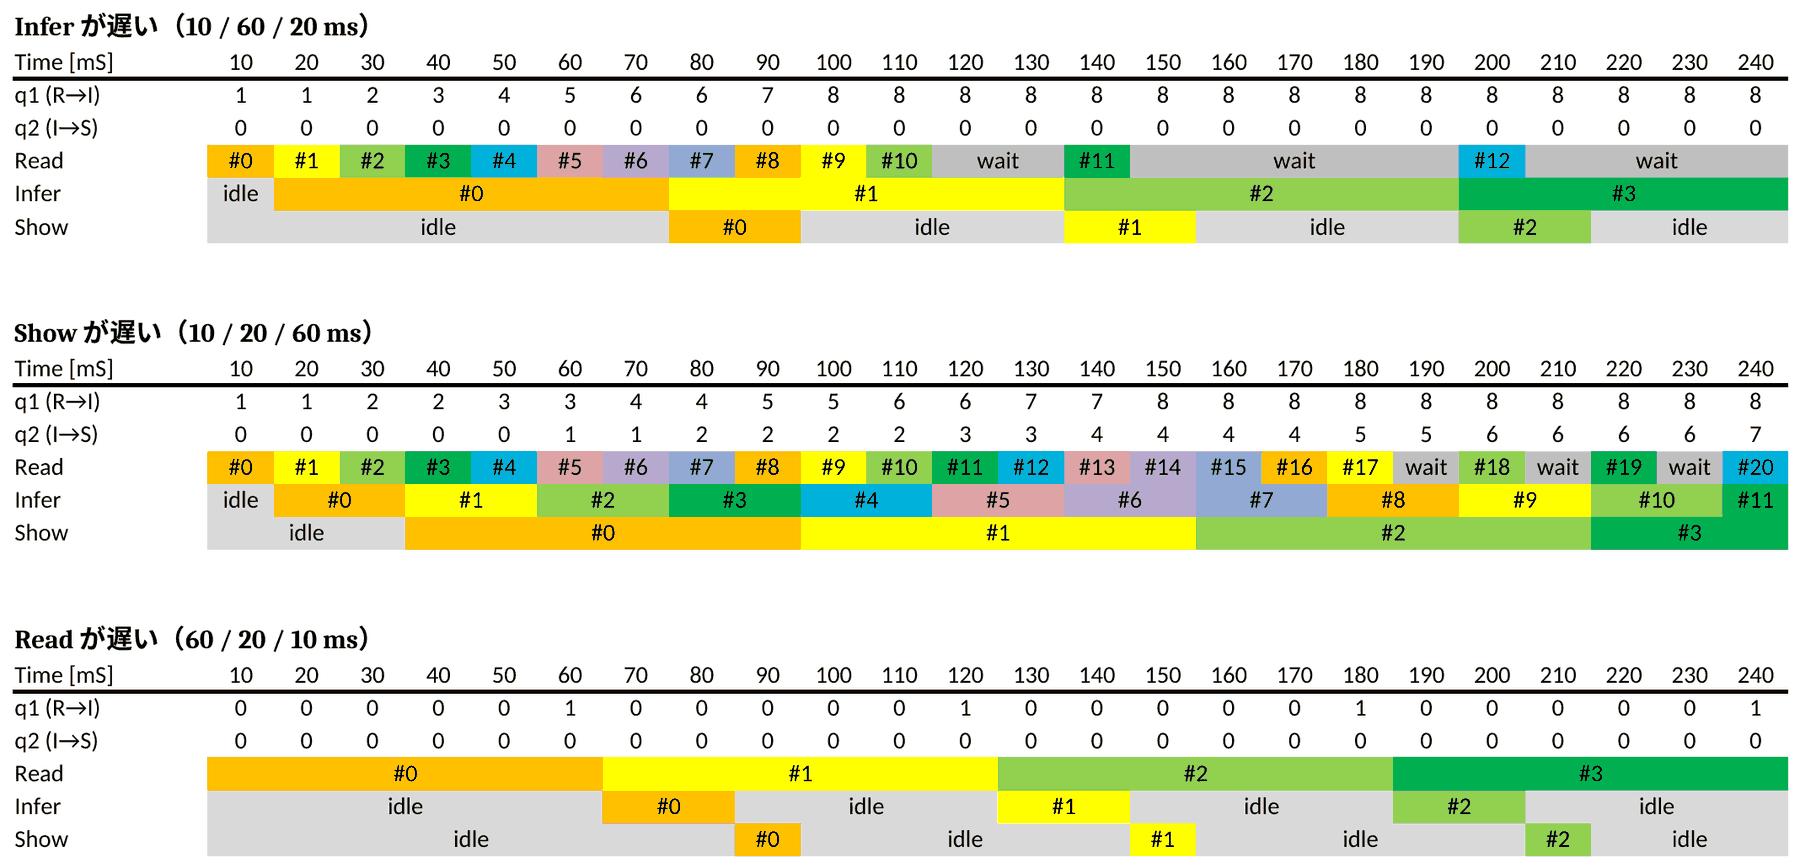

> 🔍 **図が小さいときは** [この図を原寸で開く](https://raw.githubusercontent.com/takgto/cpp-lab/main/img/pipe_33.png)（別タブ）。
> ブラウザのズーム（`Ctrl` + マウスホイール）でも拡大できます。

**「すき間のない段」と「詰まっているキューのすぐ次の段」は、いつも一致します。**
片方は段を見る方法、もう片方はキューを見る方法で、**キューを見るほうが1行で済みます。**

> **詰まっているキューのうち、いちばん下流のものを見る。その「すぐ次の段」が犯人。**
> **どのキューも空なら、犯人は一番上流（供給側）。**

`ConcurrentQueue::size()` は、まさにこの用途のためにあります
（**判断に使ってはいけない**が、**見るのはよい** ―― 発展課題2-1）。

なお3つとも FPS が同じ（16.4）なのは、どの場合も一番遅い段が 60ms だからです。
**「どこが遅いか」は FPS だけ見ていても分かりません。**

## 付録 ―― 速度倍率の測り方

演習3-2 で「速度倍率は数えるのではなく測る」と書きました。その測り方です。

やることは2つだけです。

- **同じ計算を1本のスレッド**でやって、かかった時間を測る
- **同じ計算を n 本同時**にやって、かかった時間を測る

```
速度倍率 = n × (1本のときの時間) ÷ (n本同時のときの時間)
```

- 完全に n 倍速くなれば、n本の時間は1本と同じ ⇒ 倍率は **n**
- まったく重ならなければ、n本の時間は n 倍 ⇒ 倍率は **1**

**測るのは「本物の計算」でなければなりません。** `sleep` で待つとコアを手放してしまい、
何本立てても同時に終わってしまいます（演習1-3）。ここでは中身のない足し算ループを回します。

**実行前に予測してください。** 手元のマシンは、2本にすると何倍になるでしょうか。

In [ ]:
%%writefile adv03d.cpp
// 付録  速度倍率の測り方 ―― 同じ計算を 1本 / 2本 / 3本 / 4本 でやって、時間を比べる
#include <iostream>
#include <iomanip>
#include <thread>
#include <vector>
#include <chrono>
#include <atomic>
using namespace std::chrono;

std::atomic<long> sink{0};        // 結果は捨てるが、最適化で消されないように受ける

// 中身のない足し算ループ。sleep ではなく、本当に CPU を使うのが要点
long burn(long n) { long s = 0; for (long i = 0; i < n; i++) s += (i * 2654435761u) % 7; return s; }

// n 本のスレッドで、それぞれ U 回ぶんの計算をさせて、全部終わるまでの時間(us)を返す
double run_n(long U, int n) {
    std::vector<std::thread> th;
    auto t0 = steady_clock::now();
    for (int k = 0; k < n; k++)
        th.emplace_back([&]{ sink.fetch_add(burn(U), std::memory_order_relaxed); });
    for (auto& t : th) t.join();
    return duration_cast<microseconds>(steady_clock::now() - t0).count();
}

int main() {
    // 1ms ぶんの繰り返し回数を測る
    long n = 100000, calib = 0;
    for (;;) {
        auto t0 = steady_clock::now();
        sink.fetch_add(burn(n), std::memory_order_relaxed);
        auto us = duration_cast<microseconds>(steady_clock::now() - t0).count();
        if (us > 30000) { calib = n * 1000 / us; break; }
        n *= 2;
    }

    long U = calib * 200;         // 1本あたり 200ms 分の計算（短いとぶれる）
    run_n(U, 1);                  // ウォームアップ（1回目は捨てる）
    double one = run_n(U, 1);     // これが基準

    std::cout << "hardware_concurrency() = " << std::thread::hardware_concurrency() << "\n\n"
              << std::fixed << " 本数   かかった時間   速度倍率\n";
    for (int k = 1; k <= 4; k++) {
        double t = run_n(U, k);
        std::cout << std::setw(4) << k
                  << std::setw(12) << std::setprecision(0) << t / 1000 << "ms"
                  << std::setw(11) << std::setprecision(2) << (k * one / t) << "\n";
    }
    return 0;
}

In [ ]:
!g++ -std=c++17 -pthread -O2 adv03d.cpp -o adv03d && ./adv03d
!lscpu | grep -E "^CPU\(s\)|Thread\(s\) per core|Core\(s\) per socket"

### 読み方

```
hardware_concurrency() = 2

 本数   かかった時間   速度倍率
    1         206ms       1.03
    2         390ms       1.09      ← 2本にしても 1.1倍にしかならない
    3         560ms       1.14
    4         763ms       1.11      ← 増やしても頭打ち

Core(s) per socket: 1      ← 物理コアは 1個
Thread(s) per core: 2      ← その1個を2本で分け合っている
```

- **1本のときが 1.0 前後**なら、測定は正しく動いています
- **2本で 2.0 に近ければ**、物理コアが2個ある証拠です
- **1.1 程度で頭打ちなら**、論理CPU が2つでも**物理コアは1個**です。
  `lscpu` の `Core(s) per socket` と `Thread(s) per core` で裏が取れます

**この倍率が、上限B の分母を割る数**です。

> **`hardware_concurrency()` の値からは、速度倍率はわかりません。**
> この関数が返すのは**論理CPUの数**です。
> 「物理コア1個をハイパースレッドで2本に分けたマシン（倍率 1.1）」も、
> 「物理コアが本当に2個あるマシン（倍率 2.0）」も、**どちらも 2 を返します。**
> 速度は倍ちがうのに、値は同じです。だから**マシンを変えたら、そのつど測り直してください。**